# San Francisco Rent Board Housing Inventory
## Cleaning Comparisons and Bivariate Analysis

## Step 1 — Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import json
from pathlib import Path

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
sns.set_palette('colorblind')

## Step 2 — Load the dataset

In [19]:
import csv
df = pd.read_csv("/content/Rent_Board_Housing_Inventory_20261006.csv")

## Step 3 — Inspect the original structure

In [22]:
df.info()
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 551551 entries, 0 to 551550
Data columns (total 28 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   unique_id                            551551 non-null  int64  
 1   block_num                            551549 non-null  object 
 2   unit_count                           551549 non-null  float64
 3   case_type_name                       551551 non-null  object 
 4   submission_year                      551551 non-null  int64  
 5   block_address                        551473 non-null  object 
 6   occupancy_type                       551551 non-null  object 
 7   occupancy_or_vacancy_date            448316 non-null  object 
 8   occupancy_or_vacancy_date_year       481775 non-null  object 
 9   bedroom_count                        521007 non-null  object 
 10  bathroom_count                       521101 non-null  object 
 11  square_footag

,unique_id,block_num,unit_count,case_type_name,submission_year,block_address,occupancy_type,occupancy_or_vacancy_date,occupancy_or_vacancy_date_year,bedroom_count,bathroom_count,square_footage,monthly_rent,base_rent_includes_water_sewer,base_rent_includes_natural_gas,base_rent_includes_electricity,base_rent_includes_refuse_recycling,base_rent_includes_other_utilities,past_occupancy,vacancy_date,signature_date,occupancy_or_vacancy_date_history,year_property_built,point,analysis_neighborhood,supervisor_district,data_as_of,data_loaded_at
0,-8888931167805846110,3180,173.0,Housing Inventory - Unit information (2023),2023,300 Block of BRIGHTON AVE,Occupied by non-owner,2021/06/14,2021,Two-Bedroom,Two bathrooms,1001-1250 Sq.Ft,$3751-$4000,N,N,N,N,NaN,No,NaN,2023/02/28,NaN,2012.0,POINT (-122.455200494 37.722760282),Oceanview/Merced/Ingleside,11.0,2026/10/06 01:31:04 AM,2026/10/06 06:15:55 AM
1,-8728105716412668324,3180,173.0,Housing Inventory - Unit information (2025),2025,300 Block of BRIGHTON AVE,Occupied by non-owner,2023/10/14,2023,One-Bedroom,One bathroom,751-1000 Sq.Ft,$3001-$3250,N,N,N,N,NaN,Yes,NaN,2025/02/23,"[\n {\n ""date_range_type"": ""Occupied"",\n ...",2012.0,POINT (-122.455062194 37.722760694),Oceanview/Merced/Ingleside,11.0,2026/10/06 01:31:04 AM,2026/10/06 06:15:55 AM
2,-8664205031566791701,0145,14.0,Housing Inventory - Unit information (2023),2023,0 Block of ROMOLO ST,Occupied by non-owner,1976/05/01,1976,One-Bedroom,One bathroom,501-750 Sq.Ft,$501-$750,Y,N,N,Y,NaN,No,NaN,2023/02/27,NaN,1907.0,POINT (-122.406233728 37.798263576),North Beach,3.0,2026/10/06 01:31:04 AM,2026/10/06 06:15:55 AM
3,-8198093964871002724,0285,70.0,Housing Inventory - Unit information (2023),2023,400 Block of STOCKTON ST,Occupied by non-owner,2022/12/15,2022,Studio,One bathroom,251-500 Sq.Ft,$1001-$1250,Y,N,N,Y,NaN,No,NaN,2023/02/24,NaN,1911.0,POINT (-122.407883607 37.793610704),Chinatown,3.0,2026/10/06 01:31:04 AM,2026/10/06 06:15:55 AM
4,-8126887673081079071,3180,173.0,Housing Inventory - Unit information (2022),2022,300 Block of BRIGHTON AVE,Occupied by non-owner,2021/07/25,2021,Two-Bedroom,Two bathrooms,1001-1250 Sq.Ft,$4001-$4250,N,N,N,N,NaN,Yes,NaN,2022/06/30,"[\n {\n ""end_date"": ""2021-05-22"",\n ""st...",2012.0,POINT (-122.455200494 37.722760282),Oceanview/Merced/Ingleside,11.0,2026/10/06 01:31:04 AM,2026/10/06 06:15:55 AM


## Step 4 — Create the cleaning copy

In [23]:
cleaned = df.copy(deep = True)
print('Cleaning copy created:', cleaned.shape)

Cleaning copy created: (551551, 28)


### Convert text columns to string and remove extra spaces

In [24]:
# Convert text columns to string and remove extra spaces
text_columns = [
    "block_num",
    "case_type_name",
    "block_address",
    "occupancy_type",
    "bedroom_count",
    "bathroom_count",
    "square_footage",
    "monthly_rent",
    "base_rent_includes_water_sewer",
    "base_rent_includes_natural_gas",
    "base_rent_includes_electricity",
    "base_rent_includes_refuse_recycling",
    "base_rent_includes_other_utilities",
    "past_occupancy",
    "point",
    "analysis_neighborhood",
    "supervisor_district"
]

# Using 'cleaned' as defined in cell SxAXMjdv8f-7 instead of 'cleaned'
for col in text_columns:
    if col in cleaned.columns:
        cleaned[col] = (
            cleaned[col]
            .astype("string")
            .str.strip()
        )
    elif f'"{col}"' in cleaned.columns:
        cleaned[f'"{col}"'] = (
            cleaned[f'"{col}"']
            .astype("string")
            .str.strip()
        )

## Step 8 — Convert numeric columns

In [25]:
# Strip leading and trailing double quotes from column names if present
cleaned.columns = cleaned.columns.str.replace('"', '')

numeric_columns = ['unit_count', 'submission_year', 'year_property_built']

for col in numeric_columns:
    cleaned[col] = pd.to_numeric(cleaned[col], errors='coerce')

print(cleaned[numeric_columns].dtypes)

unit_count             float64
submission_year          int64
year_property_built    float64
dtype: object


## Step 9 — Convert date columns

In [26]:
date_columns = [
    'occupancy_or_vacancy_date',
    'vacancy_date',
    'signature_date',
    'data_as_of',
    'data_loaded_at'
]

for col in date_columns:
    if col in cleaned.columns:
        cleaned[col] = pd.to_datetime(cleaned[col], errors='coerce')

print(cleaned['signature_date'].dtype)

datetime64[ns]


In [27]:
# Missing-value summary at the beginning of cleaning

missing_table = (
    cleaned.isna()
    .sum()
    .reset_index()
)

missing_table.columns = [
    "column",
    "missing_count"
]

missing_table["missing_percentage"] = (
    missing_table["missing_count"]
    / len(cleaned)
    * 100
)

missing_table = missing_table.sort_values(
    "missing_percentage",
    ascending=False
)

display(missing_table)

,column,missing_count,missing_percentage
19,vacancy_date,530409,96.166810
17,base_rent_includes_other_utilities,512939,92.999378
21,occupancy_or_vacancy_date_history,470467,85.298912
18,past_occupancy,153242,27.783831
7,occupancy_or_vacancy_date,103391,18.745501
8,occupancy_or_vacancy_date_year,69776,12.650870
12,monthly_rent,66509,12.058540
9,bedroom_count,30544,5.537838
10,bathroom_count,30450,5.520795
22,year_property_built,16002,2.901273


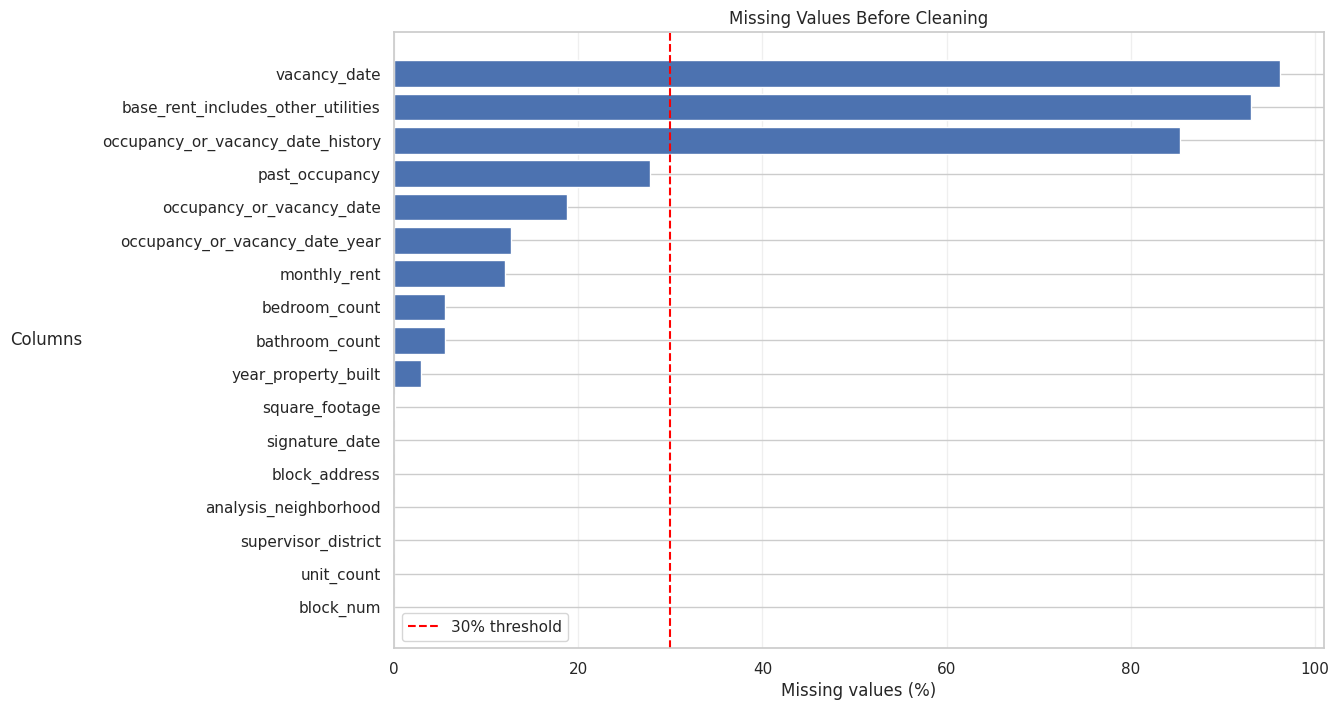

In [28]:
#Plot the graph to show missing pecentage and each column. These missing values were only identified by is_na
import matplotlib.pyplot as plt

plot_data = missing_table[
    missing_table["missing_count"] > 0
].head(20)

plt.figure(figsize=(12, 8))

plt.barh(
    plot_data["column"][::-1],
    plot_data["missing_percentage"][::-1]
)
plt.axvline(
    30,
    color="red",
    linestyle="--",
    label="30% threshold"
)

plt.xlabel("Missing values (%)")
plt.ylabel("Columns",rotation=0,labelpad=40,va="center")
plt.title("Missing Values Before Cleaning")
plt.grid(axis="x", alpha=0.3)

plt.legend()

# Presentation styling: visible ticks and horizontal labels.
ax=plt.gca()
ax.tick_params(axis="both",which="major",length=5,width=0.8,direction="out")
ax.xaxis.label.set_rotation(0)
ax.yaxis.label.set_rotation(0)
[tick.set_rotation(0) for tick in ax.get_xticklabels()]
[tick.set_rotation(0) for tick in ax.get_yticklabels()]
plt.tight_layout()
plt.show()

In [30]:
#Drop the columns with missingness greater than 30%
columns_to_drop = (
    missing_table.loc[
        missing_table["missing_percentage"] > 30,
        "column"
    ]
    .tolist()
)

print(columns_to_drop)

cleaned = cleaned.drop(columns=columns_to_drop)

['vacancy_date', 'base_rent_includes_other_utilities', 'occupancy_or_vacancy_date_history']


## Step 5 — Standardize missing values

In [33]:
#Inspect occupancy_or_vacancy_date_year column for unknown, NA, N/A and convert into None
year_col = "occupancy_or_vacancy_date_year"

year_values = (
    cleaned[year_col]
    .astype("str")
    .str.strip()
)

# Convert Unknown and other text values to null
year_values = year_values.replace(
    ["", "Unknown", "unknown", "N/A", "NA", "null"],
    pd.NA
)

cleaned[year_col] = pd.to_numeric(
    year_values,
    errors="coerce"
)

In [35]:
#Inspect for invalid years,
year_col = "occupancy_or_vacancy_date_year"

# Using 'df' and 'cleaned' which exist in your workspace instead of 'df' and 'cleaned'
original_nan = df[year_col].isna().sum()
nan_values_after_removing_unknown = cleaned[year_col].isna().sum()

#Check for invalid years with proper parentheses around comparisons
mask = (cleaned[year_col].notna() & ((cleaned[year_col] > cleaned["submission_year"]) | (cleaned[year_col] < 1800)))

#total invalid years sum
total_invalid_years = mask.sum()

#Convert invalid dates to Nan values
cleaned.loc[mask, year_col] = pd.NA

total_unusable_before = int(
    cleaned[year_col].isna().sum()
)

print(f"Original Nan Values:{original_nan}")
print(f"Nan Values after removing unknown:{nan_values_after_removing_unknown}")
print(f"Total invalid years:{total_invalid_years}")
print(f"Total unusable before filling:{total_unusable_before}")

Original Nan Values:69776
Nan Values after removing unknown:79363
Total invalid years:2371
Total unusable before filling:81734


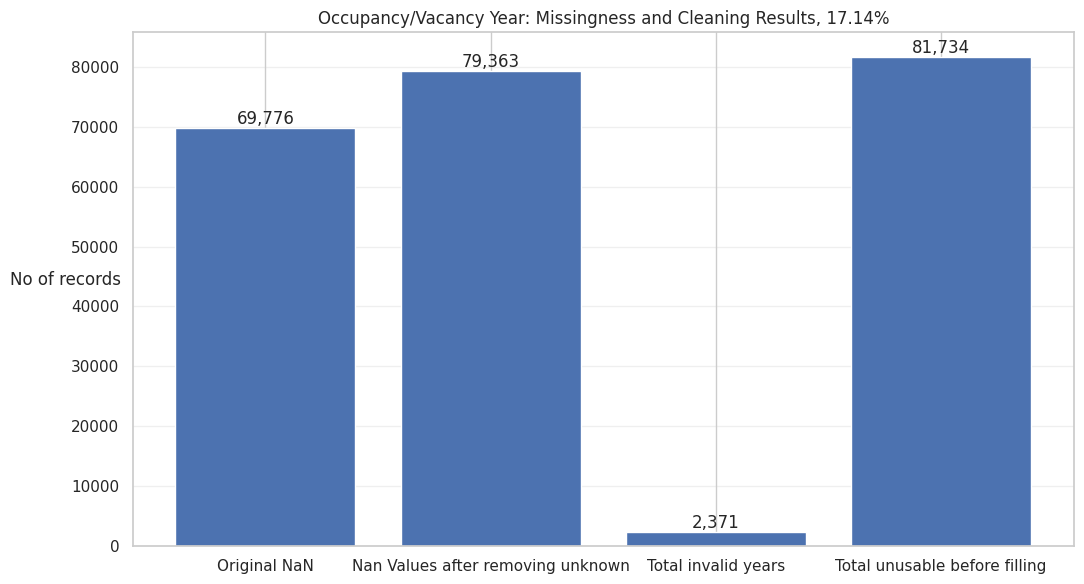

In [36]:
plot_data = pd.DataFrame({
    "stage": [
        "Original NaN",
        "Nan Values after removing unknown",
        "Total invalid years",
        "Total unusable before filling"
    ],
    "count": [
        original_nan,
        nan_values_after_removing_unknown,
        total_invalid_years,
        total_unusable_before
    ]
})

plt.figure(figsize=(11, 6))

bars = plt.bar(
    plot_data["stage"],
    plot_data["count"]
)

percentage_jump = round((total_unusable_before - original_nan)/original_nan * 100, 2)
plt.ylabel("No of records", rotation = 0)
plt.title(
    f"Occupancy/Vacancy Year: Missingness and Cleaning Results, {percentage_jump}%"
)

plt.xticks(rotation=0, ha="center")
plt.grid(axis="y", alpha=0.3)

# Add values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
# Presentation styling: visible ticks and horizontal labels.
ax=plt.gca()
ax.tick_params(axis="both",which="major",length=5,width=0.8,direction="out")
ax.xaxis.label.set_rotation(0)
ax.yaxis.label.set_rotation(0)
[tick.set_rotation(0) for tick in ax.get_xticklabels()]
[tick.set_rotation(0) for tick in ax.get_yticklabels()]
plt.tight_layout()
plt.show()

### Invalid year values were reclassified as missing

The original missing count and the final unusable count are reported separately. Invalid years are not imputed unless a valid date-derived year is available; missing target values are dropped before EDA.


In [38]:
# Dataset Notes:
#Each row is a unit. To count total units, first select a year then count unique ids.
#Do not sum unit count
#Dropping unit_count since it is unrealibale to count total units

cleaned = cleaned.drop(columns=["unit_count"])
print("unit_count" in cleaned.columns)

False


In [40]:
# Check missing IDs or duplicated unique_id's
print(
    "Missing unique_id values:",
    int(cleaned["unique_id"].isna().sum())
)

# Identify repeated IDs
duplicate_id_mask = (
    cleaned["unique_id"]
    .duplicated(keep=False)
)

print(
    "Rows with repeated unique_id:",
    int(duplicate_id_mask.sum())
)

print(
    "Number of duplicated unique_id values:",
    int(
        cleaned.loc[
            duplicate_id_mask,
            "unique_id"
        ].nunique()
    )
)

Missing unique_id values: 0
Rows with repeated unique_id: 0
Number of duplicated unique_id values: 0


In [42]:
#Drop unique_id since no duplicates and cannot be used for analysis
cleaned = cleaned.drop(
    columns=["unique_id"],
    errors="ignore"
)

In [44]:
#Creating S.NO but will be excluded from correlation matrix. Used for aggregation queries only

cleaned = cleaned.reset_index(drop=True)

cleaned["s_no"] = (
    cleaned.index + 1
)

In [46]:
#Inspect block_num column for missing and blank values

missing = int(cleaned['block_num'].isna().sum())

blank = int(
    (
       cleaned['block_num'].notna()
        & cleaned['block_num'].str.strip().eq("")
    ).sum()
)

print("Missing block_num:", missing)
print("Blank block_num:", blank)

display(
    cleaned["block_num"]
    .value_counts(dropna=False)
    .head(20)
)

Missing block_num: 2
Blank block_num: 0


,count
block_num,
8711,4542
3702,4264
3702A,4251
7335,3428
7282,3369
0198,2993
0305,2970
3783,2789
0731,2673


## Step 6 — Keep residential records

In [47]:
residential_types = [
    'Occupied by non-owner',
    'Occupied by owner',
    'Vacant'
]

cleaned = cleaned[
    cleaned['occupancy_type'].isin(residential_types)
].copy()

print('Shape after residential filtering:', cleaned.shape)

Shape after residential filtering: (548919, 24)


In [52]:
#Derive street_name from block adress before dropping the column

# Preserve block_address in df

cleaned["street_name"] = (
    cleaned["block_address"]
    .str.lower()
    .str.replace(
        r"^.*block\s+of\s+",
        "",
        regex=True
    )
    .str.strip()
    .str.upper()
)

In [54]:
display(
    cleaned[
        ["block_address", "street_name"]
    ].head(20)
)

,block_address,street_name
0,300 Block of BRIGHTON AVE,BRIGHTON AVE
1,300 Block of BRIGHTON AVE,BRIGHTON AVE
2,0 Block of ROMOLO ST,ROMOLO ST
3,400 Block of STOCKTON ST,STOCKTON ST
4,300 Block of BRIGHTON AVE,BRIGHTON AVE
5,300 Block of BRIGHTON AVE,BRIGHTON AVE
6,300 Block of BRIGHTON AVE,BRIGHTON AVE
7,200 Block of N LAKE MERCED HLS,N LAKE MERCED HLS
8,500 Block of CRESCENT CT,CRESCENT CT
9,400 Block of STOCKTON ST,STOCKTON ST


In [56]:
#All missing street names are NA values
print(
    "Missing street names:",
    int(cleaned["street_name"].isna().sum())
)

Missing street names: 76


In [58]:
#Drop block address, since street names are derived
cleaned = cleaned.drop(
    columns=["block_address"],
    errors="ignore"
)

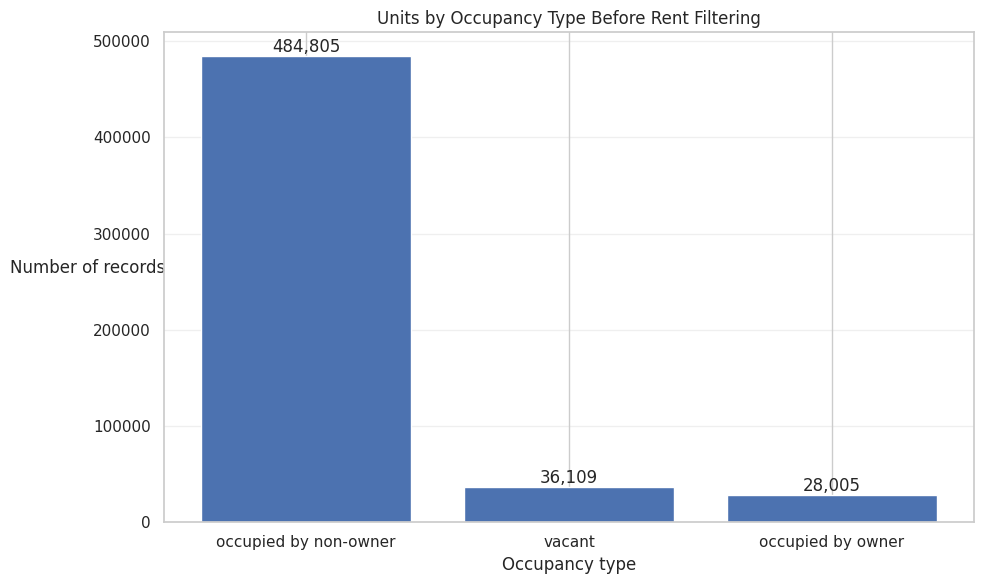

In [60]:
#inspect occupancy type
import pandas as pd
import matplotlib.pyplot as plt

occupancy_counts = (
    cleaned["occupancy_type"]
    .str.strip()
    .str.lower()
    .value_counts(dropna=False)
    .reset_index()
)

occupancy_counts.columns = [
    "occupancy_type",
    "record_count"
]


plt.figure(figsize=(10, 6))

bars = plt.bar(
    occupancy_counts["occupancy_type"].fillna("Missing"),
    occupancy_counts["record_count"]
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom"
    )

plt.xlabel("Occupancy type")
plt.ylabel("Number of records", rotation = 0)
plt.title("Units by Occupancy Type Before Rent Filtering")
plt.xticks(rotation=0, ha="center")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
# Presentation styling: visible ticks and horizontal labels.
ax=plt.gca()
ax.tick_params(axis="both",which="major",length=5,width=0.8,direction="out")
ax.xaxis.label.set_rotation(0)
ax.yaxis.label.set_rotation(0)
[tick.set_rotation(0) for tick in ax.get_xticklabels()]
[tick.set_rotation(0) for tick in ax.get_yticklabels()]
plt.tight_layout()
plt.show()

In [62]:
exclude_occupancy_types = [
    "non-residential",
    "occupied by owner"
]

occupancy_type = (
    cleaned["occupancy_type"]
    .str.strip()
    .str.lower()
)

cleaned = cleaned[
    ~occupancy_type.isin(exclude_occupancy_types)
].copy()

In [64]:
#after removal of non-residential and owner occupancy type
print("Rows remaining in cleaned:", len(cleaned))
print("Rows in df:", len(df))

Rows remaining in cleaned: 520914
Rows in df: 551551


In [66]:
rent_by_occupancy = (
    df.groupby("occupancy_type", dropna=False)
    .agg(
        total_rows=("monthly_rent", "size"),
        missing_rent=("monthly_rent", lambda x: x.isna().sum())
    )
    .reset_index()
)

rent_by_occupancy["missing_rent_percentage"] = round(
    rent_by_occupancy["missing_rent"]
    / rent_by_occupancy["total_rows"]
    * 100,
    2
)

print(rent_by_occupancy)

          occupancy_type  total_rows  missing_rent  missing_rent_percentage
0        Non-Residential        2632          2632                   100.00
1  Occupied by non-owner      484805          1895                     0.39
2      Occupied by owner       28005         28005                   100.00
3                 Vacant       36109         33977                    94.10


Non-residential and owner-occupied records were excluded from the rent-analysis dataset because they are not appropriate for predicting or analyzing monthly rent.


In [68]:
display(
    cleaned["monthly_rent"]
    .value_counts(dropna=False)
    .head(30)
)

,count
monthly_rent,
$2251-$2500,41151
$1751-$2000,40284
$2751-$3000,38510
$2501-$2750,36980
$2001-$2250,36829
$1501-$1750,36263
<NA>,35872
$1251-$1500,31845
$3001-$3250,29590


In [ ]:
# Convert monthly-rent ranges to numeric bounds and a target midpoint
rent_text = (
    cleaned["monthly_rent"]
    .astype("string")
    .str.strip()
    .str.lower()
    .str.replace(",", "", regex=False)
    .str.replace("$", "", regex=False)
)

rent_parts = rent_text.str.extract(
    r"(\d+(?:\.\d+)?)\s*[-–]\s*(\d+(?:\.\d+)?)",
    expand=True
)
rent_parts.columns = ["rent_lower_bound", "rent_upper_bound"]

rent_lower_bound = pd.to_numeric(
    rent_parts["rent_lower_bound"], errors="coerce"
)
rent_upper_bound = pd.to_numeric(
    rent_parts["rent_upper_bound"], errors="coerce"
)

# Handle open-ended values such as 7000+ only.
plus_mask = rent_text.str.contains("+", regex=False, na=False)
plus_value = pd.to_numeric(
    rent_text.where(plus_mask)
    .str.extract(r"(\d+(?:\.\d+)?)", expand=False),
    errors="coerce"
)
rent_lower_bound = rent_lower_bound.fillna(plus_value)

# Handle explicit zero-rent text without treating other values as zero.
zero_text_mask = rent_text.str.fullmatch(
    r"0(?:\.0+)?|no rent paid", na=False
)
rent_lower_bound = rent_lower_bound.mask(zero_text_mask, 0)

monthly_rent_midpoint = (rent_lower_bound + rent_upper_bound) / 2
# For open-ended values such as 7000+, use the known lower bound.
monthly_rent_midpoint = monthly_rent_midpoint.fillna(plus_value)
monthly_rent_midpoint = monthly_rent_midpoint.mask(zero_text_mask, 0)

cleaned["rent_lower_bound"] = rent_lower_bound
cleaned["rent_upper_bound"] = rent_upper_bound
cleaned["monthly_rent_midpoint"] = monthly_rent_midpoint

print("Missing target rows before dropping:", int(cleaned["monthly_rent_midpoint"].isna().sum()))
print("Missing target percentage:", round(cleaned["monthly_rent_midpoint"].isna().mean() * 100, 2))


## Step 18 — Standardize bedroom and bathroom categories

The original text values are preserved for audit. Blank and missing values remain `NaN`; valid zero values remain `0`; known labels are harmonized; and other non-missing labels are grouped as `Other`. These cleaned categories are used throughout the EDA below.


In [ ]:
# Preserve the pre-standardization values for before/after validation.
cleaned["bedroom_count_before_standardization"] = cleaned["bedroom_count"].copy()
cleaned["bathroom_count_before_standardization"] = cleaned["bathroom_count"].copy()

bedroom_map = {
    "studio": "Studio",
    "studio (sm)": "Studio",
    "zero -(studio)": "Studio",
    "zero-(studio)": "Studio",
    "one-bedroom": "One-Bedroom",
    "one bedroom": "One-Bedroom",
    "1": "One-Bedroom",
    "1 bedroom": "One-Bedroom",
    "1br": "One-Bedroom",
    "1 bed": "One-Bedroom",
    "two-bedroom": "Two-Bedroom",
    "two bedroom": "Two-Bedroom",
    "2": "Two-Bedroom",
    "2 bedroom": "Two-Bedroom",
    "2br": "Two-Bedroom",
    "2a": "Two-Bedroom",
    "2s": "Two-Bedroom",
    "2brd": "Two-Bedroom",
    "2u": "Two-Bedroom",
    "2t": "Two-Bedroom",
    "2 bedriin": "Two-Bedroom",
    "2 bedroomq": "Two-Bedroom",
    "three-bedroom": "Three-Bedroom",
    "three bedroom": "Three-Bedroom",
    "3": "Three-Bedroom",
    "3 bedroom": "Three-Bedroom",
    "3bedroom": "Three-Bedroom",
    "four-bedroom": "Four-Bedroom",
    "four bedroom": "Four-Bedroom",
    "4": "Four-Bedroom",
    "5+": "5+",
    "five-bedroom": "5+",
    "0": "0",
}

bathroom_map = {
    "one bathroom": "1", "1": "1",
    "one-bathroom": "1", "1.00": "1",
    "1 bathroom": "1", "1bathroom": "1",
    "two bathrooms": "2", "2": "2",
    "two bathroom": "2", "2 bathroom": "2",
    "2.00": "2", "two-bathroom": "2",
    "2 batroom": "2",
    "one and a half bathrooms": "1.5",
    "one and a half bathroom": "1.5",
    "one and a half bathdrooms": "1.5",
    "two and a half bathrooms": "2.5", "2.5": "2.5",
    "three bathrooms or more": "3+", "3.5": "3+",
    "shared bathroom facilities with other units": "Shared",
    "0": "0",
}

def standardize_category(series, mapping):
    normalized = series.astype("string").str.strip().str.lower()
    missing_tokens = normalized.isna() | normalized.isin(["", "nan", "none", "na", "n/a", "<na>"])
    result = normalized.map(mapping)
    result = result.mask(missing_tokens, pd.NA)
    result = result.mask(~missing_tokens & result.isna(), "Other")
    return result.astype("string")

cleaned["bedroom_count"] = standardize_category(cleaned["bedroom_count_before_standardization"], bedroom_map)
cleaned["bathroom_count"] = standardize_category(cleaned["bathroom_count_before_standardization"], bathroom_map)

print("Bedroom categories after standardization:")
display(cleaned["bedroom_count"].value_counts(dropna=False).to_frame("record_count"))
print("Bathroom categories after standardization:")
display(cleaned["bathroom_count"].value_counts(dropna=False).to_frame("record_count"))


## Step 10 — Convert utility values to binary values

In [48]:
utility_columns = [
    'base_rent_includes_water_sewer',
    'base_rent_includes_natural_gas',
    'base_rent_includes_electricity',
    'base_rent_includes_refuse_recycling',
    'base_rent_includes_other_utilities'
]

for col in utility_columns:
    if col in cleaned.columns:
        cleaned[col] = cleaned[col].map({'Y': 1, 'N': 0})

print('Utility columns converted.')

Utility columns converted.


## Step 13 — Create a midpoint conversion function

In [ ]:
# Convert square-footage text to a numeric analysis feature.
def square_footage_midpoint(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip().lower().replace(",", "")
    if text in {"", "unknown", "none", "nan", "na", "n/a"}:
        return np.nan
    numbers = [float(x) for x in re.findall(r"\d+(?:\.\d+)?", text)]
    if not numbers:
        return np.nan
    if "+" in text:
        return numbers[0]
    if len(numbers) >= 2:
        return (numbers[0] + numbers[1]) / 2
    return numbers[0]

cleaned["square_footage_midpoint"] = cleaned["square_footage"].apply(square_footage_midpoint)
print("Missing square-footage values:", int(cleaned["square_footage_midpoint"].isna().sum()))


## Step 15 — Convert square footage to a numeric feature

In [102]:
cleaned['square_footage'].value_counts(dropna=False)


,count
square_footage,
501-750 Sq.Ft,166320
751-1000 Sq.Ft,110580
251-500 Sq.Ft,109429
1001-1250 Sq.Ft,51207
0-250 Sq.Ft,33968
1251-1500 Sq.Ft,19464
Unknown,11940
1501-1750 Sq.Ft,8966
1751-2000 Sq.Ft,3992


## Step 16 — Create property age

In [105]:
cleaned.loc[
    (cleaned['year_property_built'] < 1800) |
    (cleaned['year_property_built'] > cleaned['submission_year']),
    'year_property_built'
] = np.nan

cleaned['property_age'] = (
    cleaned['submission_year'] - cleaned['year_property_built']
)

cleaned.loc[
    (cleaned['property_age'] < 0) |
    (cleaned['property_age'] > 300),
    'property_age'
] = np.nan

print(cleaned['property_age'].describe())

count    505100.000000
mean         83.445749
std          35.511083
min           1.000000
25%          60.000000
50%          98.000000
75%         113.000000
max         217.000000
Name: property_age, dtype: float64


## Step 17 — Create the bivariate analysis dataset

In [106]:
# Convert past_occupancy to binary values

cleaned["past_occupancy"] = (
    cleaned["past_occupancy"]
    .astype("string")
    .str.strip()
    .str.upper()
    .map({
        "Y": 1,
        "YES": 1,
        "N": 0,
        "NO": 0
    })
    .astype("Int64")
)

# Check results
print(cleaned["past_occupancy"].value_counts(dropna=False))

past_occupancy
0       312490
<NA>    125501
1        82923
Name: count, dtype: Int64


In [107]:
import numpy as np

cleaned["analysis_neighborhood"] = (
    cleaned["analysis_neighborhood"]
    .astype("object")
    .str.strip()
)

# Convert blanks and missing text to NaN
cleaned["analysis_neighborhood"] = (
    cleaned["analysis_neighborhood"]
    .replace(
        ["", "nan", "none", "na", "n/a", "unknown"],
        np.nan
    )
)

# Check result
print(cleaned["analysis_neighborhood"].isna().sum())
print(cleaned["analysis_neighborhood"].value_counts(dropna=False))

14
analysis_neighborhood
Nob Hill                          49575
Tenderloin                        41794
Mission                           39112
Marina                            30538
Pacific Heights                   30508
Financial District/South Beach    23673
Russian Hill                      22787
South of Market                   22202
Western Addition                  22074
Hayes Valley                      21401
Lakeshore                         20970
Outer Richmond                    19401
Chinatown                         17055
Castro/Upper Market               16778
Inner Sunset                      14625
Haight Ashbury                    13770
Mission Bay                       13441
Sunset/Parkside                   12733
Inner Richmond                    12393
North Beach                       11813
Noe Valley                         9663
Lone Mountain/USF                  8766
Potrero Hill                       8104
Presidio Heights                   7037
Twin Peaks     

In [108]:
import pandas as pd
import numpy as np

# Keep the original values temporarily
signature_raw = (
    cleaned["signature_date"]
    .astype("string")
    .str.strip()
)

# Treat blank and missing text as missing
missing_labels = ["", "nan", "none", "na", "n/a", "unknown"]

missing_mask = (
    signature_raw.isna() |
    signature_raw.str.lower().isin(missing_labels)
)

# Convert valid dates; invalid dates become NaT
signature_parsed = pd.to_datetime(
    signature_raw.where(~missing_mask),
    errors="coerce",
    format="mixed"
)

# Identify invalid non-missing values
invalid_mask = (
    signature_parsed.isna() &
    ~missing_mask
)

print("Missing signature dates:", missing_mask.sum())
print("Invalid signature dates:", invalid_mask.sum())

print("\nInvalid values:")
print(signature_raw[invalid_mask].value_counts())

# Store cleaned datetime column
cleaned["signature_date"] = signature_parsed

# Check final result
print("\nFinal missing/invalid values:",
      cleaned["signature_date"].isna().sum())

print("Datatype:",
      cleaned["signature_date"].dtype)

Missing signature dates: 127
Invalid signature dates: 0

Invalid values:
Series([], Name: count, dtype: Int64)

Final missing/invalid values: 127
Datatype: datetime64[ns]


In [110]:
# 1. Check datatype
print("Datatype:")
print(cleaned["signature_date"].dtype)

# 2. Count missing or invalid dates
print("\nMissing/invalid dates:")
print(cleaned["signature_date"].isna().sum())

# 3. Check valid date range
print("\nEarliest signature date:")
print(cleaned["signature_date"].min())

print("\nLatest signature date:")
print(cleaned["signature_date"].max())

# 4. Display cleaned values
display(
    cleaned[["signature_date"]]

)

# 5. Check whether invalid original values remain
print("\nOriginal invalid values:")
print(signature_raw[invalid_mask].value_counts())

Datatype:
datetime64[ns]

Missing/invalid dates:
127

Earliest signature date:
1974-04-26 00:00:00

Latest signature date:
2026-12-02 00:00:00


,signature_date
0,2023-02-28
1,2025-02-23
2,2023-02-27
3,2023-02-24
4,2022-06-30
...,...
551546,2025-11-23
551547,2024-02-13
551548,2025-12-15
551549,2024-03-01



Original invalid values:
Series([], Name: count, dtype: Int64)


In [111]:
print(cleaned["signature_date"].isna().sum())
print(cleaned["signature_date"].dtype)

127
datetime64[ns]


In [ ]:
point_parts=cleaned["point"].astype("string").str.extract(r"POINT\s*\(\s*(?P<longitude>-?\d+(?:\.\d+)?)\s+(?P<latitude>-?\d+(?:\.\d+)?)\s*\)")
cleaned["longitude"]=pd.to_numeric(point_parts["longitude"],errors="coerce")
cleaned["latitude"]=pd.to_numeric(point_parts["latitude"],errors="coerce")
print("Derived longitude and latitude from point.")


# Integrated EDA Based on the Cleaned Data

This EDA directly uses the `cleaned` dataframe created by the cleaning cells above. Rent, represented by `monthly_rent_midpoint`, is the target variable. The analysis examines the cleaned target and features through univariate, bivariate, and multivariate analysis before making modeling decisions.


## EDA story and guiding question

This recorded residential rental-inventory dataset is used to ask how rent varies with housing structure, location, occupancy, utilities, administrative category, and reporting time. Results describe associations in recorded inventory, not causal market effects.

**Main question:** Which housing, geographic, occupancy, and reporting characteristics are associated with differences in recorded monthly rent, and what limitations come from missingness and uneven coverage?


In [ ]:
# Create the final analysis dataset. Missing target rows are dropped, not imputed.
df_clean = cleaned.copy()
target = "monthly_rent_midpoint"
rows_before_target_drop = len(df_clean)
eda = df_clean.dropna(subset=[target]).copy()
rows_removed_for_target = rows_before_target_drop - len(eda)

print("Rows before target filtering:", rows_before_target_drop)
print("Rows removed because rent target was missing:", rows_removed_for_target)
print("Final EDA rows:", len(eda))

target_summary = eda[target].describe()
print("\nTarget summary:")
display(target_summary.to_frame().T)
print("Target skewness:", round(eda[target].skew(), 2))


## Final cleaned dataset and missingness before EDA

The following checks are completed after cleaning and column removal. Only columns still present in `cleaned` are used in the EDA below.


In [ ]:
target = "monthly_rent_midpoint"
cleaning_checks = pd.DataFrame({
    "check": [
        "negative rent target",
        "zero rent target",
        "non-positive square footage",
        "invalid property age",
        "duplicate analysis rows",
    ],
    "count": [
        int((cleaned[target] < 0).sum()),
        int((cleaned[target] == 0).sum()),
        int((cleaned["square_footage_midpoint"] <= 0).sum()),
        int(((cleaned["property_age"] < 0) | (cleaned["property_age"] > 300)).sum()),
        int(cleaned.duplicated().sum()),
    ],
})
display(cleaning_checks)
print("Remaining missingness by field:")
display(cleaned[[target, "square_footage_midpoint", "property_age", "bedroom_count", "bathroom_count", "analysis_neighborhood"]].isna().sum().to_frame("missing_count"))


In [ ]:
final_columns = pd.DataFrame({
    "column": cleaned.columns,
    "dtype": cleaned.dtypes.astype(str).values,
    "missing_count": cleaned.isna().sum().values,
})
final_columns["missing_percent"] = (
    final_columns["missing_count"] / len(cleaned) * 100
).round(2)
print("Columns present after cleaning:")
display(final_columns)
print("Columns dropped during cleaning:")
dropped_columns = [col for col in df.columns if col not in cleaned.columns]
display(pd.DataFrame({"dropped_column": dropped_columns}))
print("Missingness after cleaning, sorted from highest to lowest:")
display(final_columns.sort_values("missing_percent", ascending=False))


## EDA visualizations linked to the cleaned data

Each visual below is computed from `eda`, which is created from `cleaned` after the target and feature validation steps. Every chart states the question it is intended to answer.


## Univariate analysis

Describe one variable at a time. Numeric fields use distributions, mean, median, skewness, and missingness. Categorical and binary fields use counts, percentages, dominant groups, rare groups, and missingness.


In [ ]:
# Numeric and categorical summaries used to guide the visual choices.
print("Numeric summary:")
display(eda[[target, "square_footage_midpoint", "property_age"]].describe().T)

print("Bedroom distribution:")
display(eda["bedroom_count"].value_counts(dropna=False).to_frame("record_count"))

print("Bathroom distribution:")
display(eda["bathroom_count"].value_counts(dropna=False).to_frame("record_count"))

bedroom_rent_summary = (
    eda.dropna(subset=["bedroom_count"])
    .groupby("bedroom_count", observed=False)[target]
    .agg(record_count="count", median_rent="median", mean_rent="mean")
)
print("Rent summary by bedroom category:")
display(bedroom_rent_summary.sort_values("median_rent", ascending=False))

neighborhood_summary = (
    eda.dropna(subset=["analysis_neighborhood"])
    .groupby("analysis_neighborhood")[target]
    .agg(record_count="count", median_rent="median")
    .query("record_count >= 100")
    .sort_values("median_rent", ascending=False)
)
print("Neighborhood summary, restricted to groups with at least 100 records:")
display(neighborhood_summary.head(15))

scatter_data = eda[["square_footage_midpoint", target]].dropna().copy()
print("Rent/square-footage Pearson correlation:", round(scatter_data.corr().iloc[0, 1], 3))


## Optional RAPIDS acceleration

RAPIDS is used here for numeric summaries and grouped calculations when a compatible GPU environment is available. The resulting small tables are converted back to pandas for plotting.


In [ ]:
try:
    import cudf
    rapids_available = True
except ImportError:
    rapids_available = False
    print("RAPIDS is unavailable; CPU summaries remain the reference analysis.")

if rapids_available:
  try:
    gpu_numeric = cudf.from_pandas(
        eda[[target, "square_footage_midpoint", "property_age"]].copy()
    )
    print("RAPIDS numeric summary:")
    display(gpu_numeric.describe().to_pandas())

    gpu_bedroom = cudf.from_pandas(
        eda[["bedroom_count", target]].dropna().copy()
    )
    gpu_bedroom_summary = (
        gpu_bedroom.groupby("bedroom_count")[target]
        .agg(["count", "mean", "median"])
        .reset_index()
        .to_pandas()
    )
    display(gpu_bedroom_summary)
  except Exception as exc:
    print(f"RAPIDS computation was skipped because the current cuDF environment could not process these columns: {exc}")


## Visualization 1 — Target distribution

**Question:** What is the shape of monthly rent, and is it skewed?


In [ ]:
plot_rent = eda[target].dropna()
rent_cap = plot_rent.quantile(0.99)
plt.figure(figsize=(10, 6))
sns.histplot(plot_rent[plot_rent <= rent_cap], bins=40, kde=True, color="steelblue")
plt.axvline(plot_rent.median(), color="darkorange", linestyle="--", label=f"Median = ${plot_rent.median():,.0f}")
plt.xlabel("Monthly rent midpoint (USD)")
plt.ylabel("Number of records", rotation=0, labelpad=45, va="center")
plt.title("Distribution of Monthly Rent")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
# Presentation styling: visible ticks and horizontal labels.
ax=plt.gca()
ax.tick_params(axis="both",which="major",length=5,width=0.8,direction="out")
ax.xaxis.label.set_rotation(0)
ax.yaxis.label.set_rotation(0)
[tick.set_rotation(0) for tick in ax.get_xticklabels()]
[tick.set_rotation(0) for tick in ax.get_yticklabels()]
plt.tight_layout()
plt.show()
print("The plot is capped at the 99th percentile for readability; summary statistics use all valid target values.")


## Visualization 2 — Bedroom composition

**Question:** What bedroom categories dominate the residential records?


In [ ]:
bedroom_counts = (
    eda["bedroom_count"]
    .dropna()
    .value_counts()
    .sort_values()
)

plt.figure(figsize=(9, 6))
bedroom_counts.plot(kind="barh", color="slateblue")
plt.xlabel("Number of records")
plt.ylabel("Bedroom category", rotation=0, labelpad=55, va="center")
plt.title("Residential Records by Bedroom Category")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
# Presentation styling: visible ticks and horizontal labels.
ax=plt.gca()
ax.tick_params(axis="both",which="major",length=5,width=0.8,direction="out")
ax.xaxis.label.set_rotation(0)
ax.yaxis.label.set_rotation(0)
[tick.set_rotation(0) for tick in ax.get_xticklabels()]
[tick.set_rotation(0) for tick in ax.get_yticklabels()]
plt.tight_layout()
plt.show()


## Visualization 3 — Bathroom composition

**Question:** What bathroom categories are most common, and which values require caution?**


In [ ]:
bathroom_counts = (
    eda["bathroom_count"]
    .dropna()
    .value_counts()
    .sort_values()
)

plt.figure(figsize=(9, 6))
bathroom_counts.plot(kind="barh", color="teal")
plt.xlabel("Number of records")
plt.ylabel("Bathroom category", rotation=0, labelpad=55, va="center")
plt.title("Residential Records by Bathroom Category")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
# Presentation styling: visible ticks and horizontal labels.
ax=plt.gca()
ax.tick_params(axis="both",which="major",length=5,width=0.8,direction="out")
ax.xaxis.label.set_rotation(0)
ax.yaxis.label.set_rotation(0)
[tick.set_rotation(0) for tick in ax.get_xticklabels()]
[tick.set_rotation(0) for tick in ax.get_yticklabels()]
plt.tight_layout()
plt.show()


## Visualization 11 — Square-footage distribution

**Question:** What is the distribution and spread of housing size?**


In [ ]:
sqft_values = eda["square_footage_midpoint"].dropna()
sqft_cap = sqft_values.quantile(0.99)
plt.figure(figsize=(10, 6))
sns.histplot(sqft_values[sqft_values <= sqft_cap], bins=40, kde=True, color="darkcyan")
plt.axvline(sqft_values.median(), color="crimson", linestyle="--", label=f"Median = {sqft_values.median():,.0f}")
plt.xlabel("Square footage midpoint")
plt.ylabel("Number of records", rotation=0, labelpad=55, va="center")
plt.title("Distribution of Square Footage")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
# Presentation styling: visible ticks and horizontal labels.
ax=plt.gca()
ax.tick_params(axis="both",which="major",length=5,width=0.8,direction="out")
ax.xaxis.label.set_rotation(0)
ax.yaxis.label.set_rotation(0)
[tick.set_rotation(0) for tick in ax.get_xticklabels()]
[tick.set_rotation(0) for tick in ax.get_yticklabels()]
plt.tight_layout()
plt.show()


## Visualization 12 — Property-age distribution

**Question:** How old are the properties in the analysis dataset?**


In [ ]:
age_values = eda["property_age"].dropna()
plt.figure(figsize=(10, 6))
sns.histplot(age_values, bins=35, kde=True, color="darkorange")
plt.axvline(age_values.median(), color="navy", linestyle="--", label=f"Median = {age_values.median():,.0f} years")
plt.xlabel("Property age (years)")
plt.ylabel("Number of records", rotation=0, labelpad=55, va="center")
plt.title("Distribution of Property Age")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
# Presentation styling: visible ticks and horizontal labels.
ax=plt.gca()
ax.tick_params(axis="both",which="major",length=5,width=0.8,direction="out")
ax.xaxis.label.set_rotation(0)
ax.yaxis.label.set_rotation(0)
[tick.set_rotation(0) for tick in ax.get_xticklabels()]
[tick.set_rotation(0) for tick in ax.get_yticklabels()]
plt.tight_layout()
plt.show()


## Decision table and imputation after univariate analysis

The target is never imputed. Numeric predictors use median imputation with missingness indicators. Categorical and binary predictors use an explicit Missing category with indicators. Date fields are not blindly imputed.


In [ ]:
analysis_ready=eda.copy()
target="monthly_rent_midpoint"
numeric_impute_columns=[c for c in ["square_footage_midpoint","property_age","year_property_built"] if c in analysis_ready.columns]
categorical_impute_columns=[c for c in ["bedroom_count","bathroom_count","analysis_neighborhood","street_name","case_type_name","occupancy_type","supervisor_district","past_occupancy"] if c in analysis_ready.columns]
impute_columns=numeric_impute_columns+categorical_impute_columns
for col in impute_columns:
    analysis_ready[f"{col}_was_missing"]=analysis_ready[col].isna().astype("int8")
for col in numeric_impute_columns:
    analysis_ready[col]=analysis_ready[col].fillna(analysis_ready[col].median())
for col in categorical_impute_columns:
    analysis_ready[col]=analysis_ready[col].astype("string").fillna("Missing")
imputation_decisions=pd.DataFrame([[target,"target","Drop missing rows; never impute","Imputing rent invents the response"],["square footage, property age, year built","numeric predictors","Median plus indicator","Robust to skew"],["bedroom, bathroom","categorical/ordinal","Missing category plus indicator","Mean/median creates artificial categories"],["neighborhood, street, case type, occupancy, district, past occupancy","categorical/binary","Missing category plus indicator","Missingness may carry information"],["date fields","temporal","Do not blindly impute","Use valid dates or derived years only"]],columns=["Columns","Role","Imputation method","Reason"])
display(imputation_decisions)
display(analysis_ready[impute_columns].isna().sum())


## Why these features are selected for further analysis

- `monthly_rent_midpoint` is the target, so major comparisons connect back to rent.
- Bedrooms, bathrooms, and square footage describe housing size and structure.
- Property age represents building characteristics.
- Neighborhood, street, supervisor district, latitude, and longitude represent location.
- Occupancy type and past occupancy describe rental status and history.
- Utility fields describe what is included in base rent.
- Case type and submission year provide administrative and temporal context.
- Identifiers, metadata, and dropped fields are excluded because they do not describe housing characteristics.


## Bivariate analysis

Use `analysis_ready` to compare important predictors with rent. Median rent is emphasized because the target may be skewed.

**Questions:** Does rent differ by bedroom, bathroom, neighborhood, supervisor district, occupancy type, utility inclusion, past occupancy, submission type, submission year, and frequently represented street? Do larger units generally have higher rent, and does property age relate to rent?


## Visualization 4 — Rent by bedroom category

**Question:** Does rent vary across bedroom categories?


In [ ]:
bedroom_order = ["0", "Studio", "One-Bedroom", "Two-Bedroom", "Three-Bedroom", "Four-Bedroom", "5+", "Other"]
available_bedrooms = [x for x in bedroom_order if x in analysis_ready["bedroom_count"].dropna().unique()]
box_data = analysis_ready[analysis_ready["bedroom_count"].isin(available_bedrooms)].copy()

plt.figure(figsize=(10, 6))
sns.boxplot(data=box_data, x=target, y="bedroom_count", order=available_bedrooms, showfliers=False, color="cornflowerblue")
plt.xlim(0, box_data[target].quantile(0.99))
plt.xlabel("Monthly rent midpoint (USD)")
plt.ylabel("Bedroom category", rotation=0, labelpad=55, va="center")
plt.title("Monthly Rent Distribution by Bedroom Category")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
# Presentation styling: visible ticks and horizontal labels.
ax=plt.gca()
ax.tick_params(axis="both",which="major",length=5,width=0.8,direction="out")
ax.xaxis.label.set_rotation(0)
ax.yaxis.label.set_rotation(0)
[tick.set_rotation(0) for tick in ax.get_xticklabels()]
[tick.set_rotation(0) for tick in ax.get_yticklabels()]
plt.tight_layout()
plt.show()

bedroom_rent_summary = (
    box_data.groupby("bedroom_count", observed=False)[target]
    .agg(record_count="count", median_rent="median", mean_rent="mean")
    .reindex(available_bedrooms)
)
display(bedroom_rent_summary)


## Visualization 5 — Rent and square footage

**Question:** Do larger units generally have higher monthly rent?**


In [ ]:
scatter_data = analysis_ready[["square_footage_midpoint", target]].dropna().copy()
scatter_sample = scatter_data.sample(n=min(10000, len(scatter_data)), random_state=42)

plt.figure(figsize=(10, 6))
sns.regplot(data=scatter_sample, x="square_footage_midpoint", y=target,
            scatter_kws={"alpha": 0.18, "s": 18}, line_kws={"color": "crimson"})
plt.ylim(0, scatter_data[target].quantile(0.99))
plt.xlabel("Square footage midpoint")
plt.ylabel("Monthly rent midpoint (USD)", rotation=0, labelpad=55, va="center")
plt.title("Monthly Rent versus Square Footage")
plt.grid(alpha=0.3)
plt.tight_layout()
# Presentation styling: visible ticks and horizontal labels.
ax=plt.gca()
ax.tick_params(axis="both",which="major",length=5,width=0.8,direction="out")
ax.xaxis.label.set_rotation(0)
ax.yaxis.label.set_rotation(0)
[tick.set_rotation(0) for tick in ax.get_xticklabels()]
[tick.set_rotation(0) for tick in ax.get_yticklabels()]
plt.tight_layout()
plt.show()
print("Pearson correlation:", round(scatter_data.corr().iloc[0, 1], 3))


## Visualization 6 — Neighborhood rent differences

**Question:** Does typical monthly rent differ across neighborhoods?**


In [ ]:
neighborhood_summary = (
    analysis_ready.dropna(subset=["analysis_neighborhood"])
    .groupby("analysis_neighborhood")[target]
    .agg(record_count="count", median_rent="median")
    .query("record_count >= 100")
    .sort_values("median_rent")
    .tail(15)
)

plt.figure(figsize=(10, 7))
plt.barh(neighborhood_summary.index, neighborhood_summary["median_rent"], color="seagreen")
plt.xlabel("Median monthly rent midpoint (USD)")
plt.ylabel("Neighborhood", rotation=0, labelpad=55, va="center")
plt.title("Median Rent in the 15 Highest-Rent Neighborhoods")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
# Presentation styling: visible ticks and horizontal labels.
ax=plt.gca()
ax.tick_params(axis="both",which="major",length=5,width=0.8,direction="out")
ax.xaxis.label.set_rotation(0)
ax.yaxis.label.set_rotation(0)
[tick.set_rotation(0) for tick in ax.get_xticklabels()]
[tick.set_rotation(0) for tick in ax.get_yticklabels()]
plt.tight_layout()
plt.show()
display(neighborhood_summary.sort_values("median_rent", ascending=False))


## Visualization 7 — Rent by occupancy type

**Question:** Does the typical rent differ between occupied-by-non-owner and vacant records?**


In [ ]:
occupancy_rent_data = analysis_ready.dropna(subset=["occupancy_type", target]).copy()
occupancy_order = occupancy_rent_data.groupby("occupancy_type")[target].median().sort_values().index.tolist()

plt.figure(figsize=(10, 6))
sns.boxplot(data=occupancy_rent_data, x=target, y="occupancy_type", order=occupancy_order, showfliers=False, color="mediumpurple")
plt.xlim(0, occupancy_rent_data[target].quantile(0.99))
plt.xlabel("Monthly rent midpoint (USD)")
plt.ylabel("Occupancy type", rotation=0, labelpad=55, va="center")
plt.title("Monthly Rent by Occupancy Type")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
# Presentation styling: visible ticks and horizontal labels.
ax=plt.gca()
ax.tick_params(axis="both",which="major",length=5,width=0.8,direction="out")
ax.xaxis.label.set_rotation(0)
ax.yaxis.label.set_rotation(0)
[tick.set_rotation(0) for tick in ax.get_xticklabels()]
[tick.set_rotation(0) for tick in ax.get_yticklabels()]
plt.tight_layout()
plt.show()


## Visualization 8 — Rent by property-age group

**Question:** Does typical rent vary by property age?**


In [ ]:
age_plot_data = analysis_ready.dropna(subset=["property_age", target]).copy()
age_bins = [-1, 10, 25, 50, 100, 300]
age_labels = ["0–10 years", "11–25 years", "26–50 years", "51–100 years", "Over 100 years"]
age_plot_data["property_age_group"] = pd.cut(age_plot_data["property_age"], bins=age_bins, labels=age_labels)

plt.figure(figsize=(10, 6))
sns.boxplot(data=age_plot_data, x=target, y="property_age_group", order=age_labels, showfliers=False, color="darkcyan")
plt.xlim(0, age_plot_data[target].quantile(0.99))
plt.xlabel("Monthly rent midpoint (USD)")
plt.ylabel("Property age group", rotation=0, labelpad=65, va="center")
plt.title("Monthly Rent by Property-Age Group")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
# Presentation styling: visible ticks and horizontal labels.
ax=plt.gca()
ax.tick_params(axis="both",which="major",length=5,width=0.8,direction="out")
ax.xaxis.label.set_rotation(0)
ax.yaxis.label.set_rotation(0)
[tick.set_rotation(0) for tick in ax.get_xticklabels()]
[tick.set_rotation(0) for tick in ax.get_yticklabels()]
plt.tight_layout()
plt.show()


## Visualization 9 — Missingness relevant to EDA

**Question:** Which analysis features still have missing values, and where is imputation potentially needed?**


In [ ]:
feature_missing = (
    analysis_ready[[target, "square_footage_midpoint", "property_age", "bedroom_count", "bathroom_count", "analysis_neighborhood"]]
    .isna()
    .mean()
    .mul(100)
    .sort_values()
)

plt.figure(figsize=(9, 5))
feature_missing.plot(kind="barh", color="darkorange")
plt.xlabel("Missing values (%)")
plt.ylabel("Feature", rotation=0, labelpad=45, va="center")
plt.title("Missingness in Variables Used for EDA")
plt.xlim(0, max(5, feature_missing.max() * 1.15))
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
# Presentation styling: visible ticks and horizontal labels.
ax=plt.gca()
ax.tick_params(axis="both",which="major",length=5,width=0.8,direction="out")
ax.xaxis.label.set_rotation(0)
ax.yaxis.label.set_rotation(0)
[tick.set_rotation(0) for tick in ax.get_xticklabels()]
[tick.set_rotation(0) for tick in ax.get_yticklabels()]
plt.tight_layout()
plt.show()
display(feature_missing.to_frame("missing_percentage"))


## Multivariate analysis

Use only the strongest features identified in the univariate and bivariate sections. These plots show whether one relationship changes across another feature or group.

**Questions:** Does the bedroom–rent relationship differ by neighborhood or submission year? Does the rent–size relationship differ by occupancy type? Do bedroom and bathroom combinations jointly distinguish rent? Does submission type vary by occupancy type?


## Visualization 10 — Multivariate correlation heatmap

**Question:** Which numeric housing characteristics move with rent, considered together?**


In [ ]:
bedroom_numeric_map = {
    "0": 0, "Studio": 0, "One-Bedroom": 1,
    "Two-Bedroom": 2, "Three-Bedroom": 3,
    "Four-Bedroom": 4, "5+": 5
}
bathroom_numeric_map = {
    "1": 1.0, "1.5": 1.5, "2": 2.0,
    "2.5": 2.5, "3+": 3.0
}
corr_data = pd.DataFrame({
    "Rent": analysis_ready[target],
    "Square footage": analysis_ready["square_footage_midpoint"],
    "Property age": analysis_ready["property_age"],
    "Bedrooms": analysis_ready["bedroom_count"].map(bedroom_numeric_map),
    "Bathrooms": analysis_ready["bathroom_count"].map(bathroom_numeric_map),
})
corr_matrix = corr_data.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1)
plt.title("Correlation Matrix of Numeric EDA Variables")
plt.tight_layout()
# Presentation styling: visible ticks and horizontal labels.
ax=plt.gca()
ax.tick_params(axis="both",which="major",length=5,width=0.8,direction="out")
ax.xaxis.label.set_rotation(0)
ax.yaxis.label.set_rotation(0)
[tick.set_rotation(0) for tick in ax.get_xticklabels()]
[tick.set_rotation(0) for tick in ax.get_yticklabels()]
plt.tight_layout()
plt.show()
display(corr_matrix["Rent"].sort_values(ascending=False).to_frame("Correlation with rent"))


## Cleaning validation visualizations

These figures show the effect of validation and target filtering before interpreting the cleaned data.


In [ ]:
cleaning_stage_plot = pd.DataFrame({
    "stage": ["Original missing rent", "Unusable rent before EDA", "Rows removed for missing target"],
    "records": [
        int(df["monthly_rent"].isna().sum()),
        int(cleaned["monthly_rent_midpoint"].isna().sum()),
        int(rows_removed_for_target),
    ],
})

plt.figure(figsize=(10, 5))
bars = plt.bar(cleaning_stage_plot["stage"], cleaning_stage_plot["records"], color=["gray", "darkorange", "crimson"])
plt.xlabel("Cleaning stage")
plt.ylabel("Number of records", rotation=0, labelpad=55, va="center")
plt.title("Rent-Target Cleaning and Filtering")
plt.xticks(rotation=0, ha="center")
plt.grid(axis="y", alpha=0.3)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{int(bar.get_height()):,}", ha="center", va="bottom")
plt.tight_layout()
# Presentation styling: visible ticks and horizontal labels.
ax=plt.gca()
ax.tick_params(axis="both",which="major",length=5,width=0.8,direction="out")
ax.xaxis.label.set_rotation(0)
ax.yaxis.label.set_rotation(0)
[tick.set_rotation(0) for tick in ax.get_xticklabels()]
[tick.set_rotation(0) for tick in ax.get_yticklabels()]
plt.tight_layout()
plt.show()


### Bedroom standardization check

**Question:** How did the bedroom categories change from the original labels to the cleaned labels used in EDA?


In [ ]:
raw_bedroom_counts = cleaned["bedroom_count_before_standardization"].astype("string").str.strip().replace("", pd.NA).fillna("Missing").value_counts()
clean_bedroom_counts = cleaned["bedroom_count"].fillna("Missing").value_counts()
bedroom_compare = pd.DataFrame({"Before standardization": raw_bedroom_counts, "After standardization": clean_bedroom_counts}).fillna(0)
bedroom_compare = bedroom_compare.sort_values("After standardization", ascending=True).tail(12)

bedroom_compare.plot(kind="barh", figsize=(11, 7), color=["lightgray", "slateblue"] )
plt.xlabel("Number of records")
plt.ylabel("Bedroom category", rotation=0, labelpad=55, va="center")
plt.title("Bedroom Categories Before and After Standardization")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
# Presentation styling: visible ticks and horizontal labels.
ax=plt.gca()
ax.tick_params(axis="both",which="major",length=5,width=0.8,direction="out")
ax.xaxis.label.set_rotation(0)
ax.yaxis.label.set_rotation(0)
[tick.set_rotation(0) for tick in ax.get_xticklabels()]
[tick.set_rotation(0) for tick in ax.get_yticklabels()]
plt.tight_layout()
plt.show()


### Bathroom standardization check

**Question:** Which bathroom labels were consolidated before the rent analysis?


In [ ]:
raw_bathroom_counts = cleaned["bathroom_count_before_standardization"].astype("string").str.strip().replace("", pd.NA).fillna("Missing").value_counts()
clean_bathroom_counts = cleaned["bathroom_count"].fillna("Missing").value_counts()
bathroom_compare = pd.DataFrame({"Before standardization": raw_bathroom_counts, "After standardization": clean_bathroom_counts}).fillna(0)
bathroom_compare = bathroom_compare.sort_values("After standardization", ascending=True).tail(12)

bathroom_compare.plot(kind="barh", figsize=(11, 7), color=["lightgray", "seagreen"] )
plt.xlabel("Number of records")
plt.ylabel("Bathroom category", rotation=0, labelpad=55, va="center")
plt.title("Bathroom Categories Before and After Standardization")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
# Presentation styling: visible ticks and horizontal labels.
ax=plt.gca()
ax.tick_params(axis="both",which="major",length=5,width=0.8,direction="out")
ax.xaxis.label.set_rotation(0)
ax.yaxis.label.set_rotation(0)
[tick.set_rotation(0) for tick in ax.get_xticklabels()]
[tick.set_rotation(0) for tick in ax.get_yticklabels()]
plt.tight_layout()
plt.show()


## Visualization 13 — Rent by bathroom category

**Question:** Does rent vary across bathroom categories?**


In [ ]:
bathroom_order = ["1", "1.5", "2", "2.5", "3+", "Shared", "Other"]
available_bathrooms = [x for x in bathroom_order if x in analysis_ready["bathroom_count"].dropna().unique()]
bathroom_box_data = analysis_ready[analysis_ready["bathroom_count"].isin(available_bathrooms)].copy()

plt.figure(figsize=(10, 6))
sns.boxplot(data=bathroom_box_data, x=target, y="bathroom_count", order=available_bathrooms, showfliers=False, color="mediumseagreen")
plt.xlim(0, bathroom_box_data[target].quantile(0.99))
plt.xlabel("Monthly rent midpoint (USD)")
plt.ylabel("Bathroom category", rotation=0, labelpad=55, va="center")
plt.title("Monthly Rent by Bathroom Category")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
# Presentation styling: visible ticks and horizontal labels.
ax=plt.gca()
ax.tick_params(axis="both",which="major",length=5,width=0.8,direction="out")
ax.xaxis.label.set_rotation(0)
ax.yaxis.label.set_rotation(0)
[tick.set_rotation(0) for tick in ax.get_xticklabels()]
[tick.set_rotation(0) for tick in ax.get_yticklabels()]
plt.tight_layout()
plt.show()


## Visualization 14 — Rent versus property age

**Question:** Is property age associated with monthly rent?**


In [ ]:
age_rent_data = analysis_ready[["property_age", target]].dropna().copy()
age_rent_sample = age_rent_data.sample(n=min(10000, len(age_rent_data)), random_state=42)
plt.figure(figsize=(10, 6))
sns.regplot(data=age_rent_sample, x="property_age", y=target, scatter_kws={"alpha": 0.18, "s": 18}, line_kws={"color": "crimson"})
plt.ylim(0, age_rent_data[target].quantile(0.99))
plt.xlabel("Property age (years)")
plt.ylabel("Monthly rent midpoint (USD)", rotation=0, labelpad=55, va="center")
plt.title("Monthly Rent versus Property Age")
plt.grid(alpha=0.3)
plt.tight_layout()
# Presentation styling: visible ticks and horizontal labels.
ax=plt.gca()
ax.tick_params(axis="both",which="major",length=5,width=0.8,direction="out")
ax.xaxis.label.set_rotation(0)
ax.yaxis.label.set_rotation(0)
[tick.set_rotation(0) for tick in ax.get_xticklabels()]
[tick.set_rotation(0) for tick in ax.get_yticklabels()]
plt.tight_layout()
plt.show()
print("Pearson correlation:", round(age_rent_data.corr().iloc[0, 1], 3))


## Visualization 15A — Rent by past-occupancy status

**Question:** Does rent differ by past-occupancy status?

This feature is selected because it describes rental history and may distinguish record types.


In [ ]:
past_occupancy_summary=analysis_ready.groupby("past_occupancy")[target].agg(record_count="count",median_rent="median").reset_index()
past_occupancy_summary["label"]=past_occupancy_summary["past_occupancy"].map({1:"Yes",0:"No","Missing":"Missing"}).fillna(past_occupancy_summary["past_occupancy"].astype(str))
plt.figure(figsize=(8,5))
sns.barplot(data=past_occupancy_summary,x="label",y="median_rent",color="#E69F00")
plt.xlabel("Past occupancy status")
plt.ylabel("Median monthly rent (USD)",rotation=0,labelpad=75,va="center")
plt.title("Median Rent by Past-Occupancy Status")
plt.grid(axis="y",alpha=0.3)
ax=plt.gca(); ax.tick_params(axis="both",which="major",length=5,width=0.8,direction="out"); plt.tight_layout(); plt.show()
display(past_occupancy_summary)


## Visualization 15 — Rent by included utility

**Question:** Do median rents differ when utilities are included in the base rent?**


In [ ]:
utility_labels = {
    "base_rent_includes_water_sewer": "Water / sewer",
    "base_rent_includes_natural_gas": "Natural gas",
    "base_rent_includes_electricity": "Electricity",
    "base_rent_includes_refuse_recycling": "Refuse / recycling",
    "base_rent_includes_other_utilities": "Other utilities",
}
utility_rows = []
for col, label in utility_labels.items():
    if col in analysis_ready.columns:
        temp = analysis_ready[[col, target]].dropna().copy()
        temp["Utility"] = label
        temp["Utility status"] = temp[col].map({1: "Included", 0: "Not included"})
        utility_rows.append(temp[["Utility", "Utility status", target]])
utility_plot_data = pd.concat(utility_rows, ignore_index=True)
utility_summary = utility_plot_data.groupby(["Utility", "Utility status"])[target].median().reset_index(name="median_rent")

plt.figure(figsize=(11, 6))
sns.barplot(data=utility_summary, x="Utility", y="median_rent", hue="Utility status", palette={"Included": "seagreen", "Not included": "lightgray"})
plt.xlabel("Utility")
plt.ylabel("Median monthly rent (USD)", rotation=0, labelpad=70, va="center")
plt.title("Median Rent by Utility-Inclusion Status")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
# Presentation styling: visible ticks and horizontal labels.
ax=plt.gca()
ax.tick_params(axis="both",which="major",length=5,width=0.8,direction="out")
ax.xaxis.label.set_rotation(0)
ax.yaxis.label.set_rotation(0)
[tick.set_rotation(0) for tick in ax.get_xticklabels()]
[tick.set_rotation(0) for tick in ax.get_yticklabels()]
plt.tight_layout()
plt.show()


## Visualization 16 — Bedroom and bathroom rent heatmap

**Question:** How does median rent vary across bedroom and bathroom combinations?**


In [ ]:
bedroom_numeric = analysis_ready["bedroom_count"].map({"0": 0, "Studio": 0, "One-Bedroom": 1, "Two-Bedroom": 2, "Three-Bedroom": 3, "Four-Bedroom": 4, "5+": 5})
bathroom_numeric = analysis_ready["bathroom_count"].map({"1": 1, "1.5": 1.5, "2": 2, "2.5": 2.5, "3+": 3})
combination_data = pd.DataFrame({"Bedrooms": bedroom_numeric, "Bathrooms": bathroom_numeric, target: analysis_ready[target]}).dropna()
rent_combo = combination_data.pivot_table(index="Bedrooms", columns="Bathrooms", values=target, aggfunc="median")

plt.figure(figsize=(9, 6))
sns.heatmap(rent_combo, annot=True, fmt=".0f", cmap="YlOrRd", linewidths=0.5, cbar_kws={"label": "Median rent (USD)"})
plt.xlabel("Bathrooms")
plt.ylabel("Bedrooms", rotation=0, labelpad=45, va="center")
plt.title("Median Rent by Bedroom and Bathroom Combination")
plt.tight_layout()
# Presentation styling: visible ticks and horizontal labels.
ax=plt.gca()
ax.tick_params(axis="both",which="major",length=5,width=0.8,direction="out")
ax.xaxis.label.set_rotation(0)
ax.yaxis.label.set_rotation(0)
[tick.set_rotation(0) for tick in ax.get_xticklabels()]
[tick.set_rotation(0) for tick in ax.get_yticklabels()]
plt.tight_layout()
plt.show()


## Visualization 17 — Rent and square footage by occupancy type

**Question:** Does the rent–size relationship look similar across occupancy types?**


In [ ]:
facet_data = analysis_ready[["occupancy_type", "square_footage_midpoint", target]].dropna().copy()
facet_data = facet_data.sample(n=min(8000, len(facet_data)), random_state=42)
facet_grid = sns.FacetGrid(facet_data, col="occupancy_type", col_wrap=2, height=4, sharex=True, sharey=True)
facet_grid.map_dataframe(sns.scatterplot, x="square_footage_midpoint", y=target, alpha=0.18, s=15, color="indigo")
facet_grid.set_axis_labels("Square footage midpoint", "Monthly rent midpoint (USD)")
facet_grid.set_titles("{col_name}")
for ax in facet_grid.axes.flat:
    ax.set_ylabel("Monthly rent midpoint (USD)", rotation=0, labelpad=70, va="center")
    ax.set_ylim(0, facet_data[target].quantile(0.99))
facet_grid.fig.suptitle("Rent versus Size by Occupancy Type", y=1.02)
plt.tight_layout()
# Presentation styling: visible ticks and horizontal labels.
ax=plt.gca()
ax.tick_params(axis="both",which="major",length=5,width=0.8,direction="out")
ax.xaxis.label.set_rotation(0)
ax.yaxis.label.set_rotation(0)
[tick.set_rotation(0) for tick in ax.get_xticklabels()]
[tick.set_rotation(0) for tick in ax.get_yticklabels()]
plt.tight_layout()
plt.show()


## Administrative, geographic, and temporal analysis

These analyses use submission type, submission year, street, neighborhood, supervisor district, and cleaned date fields. They are included because these columns can explain differences in the rent records and document where the data are concentrated.


### Administrative and geographic coverage

**Question:** Which administrative and geographic fields are available after cleaning, and how much information do they contain?


In [ ]:
coverage_columns = [
    "case_type_name", "submission_year", "street_name",
    "analysis_neighborhood", "supervisor_district",
    "occupancy_or_vacancy_date", "occupancy_or_vacancy_date_year",
    "signature_date", "past_occupancy",
]
coverage_columns = [col for col in coverage_columns if col in analysis_ready.columns]
coverage_table = pd.DataFrame({
    "non_missing_count": analysis_ready[coverage_columns].notna().sum(),
    "missing_percentage": analysis_ready[coverage_columns].isna().mean().mul(100).round(2),
})
display(coverage_table.sort_values("missing_percentage"))


## Visualization 18 — Submission type composition

**Question:** Which submission or case types make up the cleaned rent-analysis records?


In [ ]:
case_counts = analysis_ready["case_type_name"].dropna().value_counts().sort_values()
plt.figure(figsize=(10, 7))
case_counts.plot(kind="barh", color="#4C78A8")
plt.xlabel("Number of records")
plt.ylabel("Submission type", rotation=0, labelpad=55, va="center")
plt.title("Cleaned Records by Submission Type")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
# Presentation styling: visible ticks and horizontal labels.
ax=plt.gca()
ax.tick_params(axis="both",which="major",length=5,width=0.8,direction="out")
ax.xaxis.label.set_rotation(0)
ax.yaxis.label.set_rotation(0)
[tick.set_rotation(0) for tick in ax.get_xticklabels()]
[tick.set_rotation(0) for tick in ax.get_yticklabels()]
plt.tight_layout()
plt.show()


## Visualization 19 — Submission-year distribution

**Question:** Over which submission years are the rent records concentrated?


In [ ]:
submission_counts = analysis_ready["submission_year"].dropna().astype(int).value_counts().sort_index()
plt.figure(figsize=(11, 5))
plt.bar(submission_counts.index.astype(str), submission_counts.values, color="#F58518")
plt.xlabel("Submission year")
plt.ylabel("Number of records", rotation=0, labelpad=55, va="center")
plt.title("Records by Submission Year")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
# Presentation styling: visible ticks and horizontal labels.
ax=plt.gca()
ax.tick_params(axis="both",which="major",length=5,width=0.8,direction="out")
ax.xaxis.label.set_rotation(0)
ax.yaxis.label.set_rotation(0)
[tick.set_rotation(0) for tick in ax.get_xticklabels()]
[tick.set_rotation(0) for tick in ax.get_yticklabels()]
plt.tight_layout()
plt.show()


## Visualization 20 — Street composition

**Question:** Which streets have enough cleaned records to support stable comparisons?


In [ ]:
street_counts = analysis_ready["street_name"].dropna().value_counts().head(20).sort_values()
plt.figure(figsize=(11, 8))
street_counts.plot(kind="barh", color="#54A24B")
plt.xlabel("Number of records")
plt.ylabel("Street", rotation=0, labelpad=55, va="center")
plt.title("Top Streets by Number of Cleaned Records")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
# Presentation styling: visible ticks and horizontal labels.
ax=plt.gca()
ax.tick_params(axis="both",which="major",length=5,width=0.8,direction="out")
ax.xaxis.label.set_rotation(0)
ax.yaxis.label.set_rotation(0)
[tick.set_rotation(0) for tick in ax.get_xticklabels()]
[tick.set_rotation(0) for tick in ax.get_yticklabels()]
plt.tight_layout()
plt.show()


## Visualization 21 — Supervisor-district composition

**Question:** How are the cleaned rent records distributed across supervisor districts?


In [ ]:
district_counts = analysis_ready["supervisor_district"].astype("string").fillna("Missing").value_counts().sort_values()
plt.figure(figsize=(9, 6))
district_counts.plot(kind="barh", color="#B279A2")
plt.xlabel("Number of records")
plt.ylabel("Supervisor district", rotation=0, labelpad=55, va="center")
plt.title("Records by Supervisor District")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
# Presentation styling: visible ticks and horizontal labels.
ax=plt.gca()
ax.tick_params(axis="both",which="major",length=5,width=0.8,direction="out")
ax.xaxis.label.set_rotation(0)
ax.yaxis.label.set_rotation(0)
[tick.set_rotation(0) for tick in ax.get_xticklabels()]
[tick.set_rotation(0) for tick in ax.get_yticklabels()]
plt.tight_layout()
plt.show()


## Visualization 22 — Date-field coverage after cleaning

**Question:** Which date fields are usable for temporal EDA after invalid values were converted to missing?


In [ ]:
date_fields = [col for col in ["occupancy_or_vacancy_date", "signature_date", "data_as_of", "data_loaded_at"] if col in analysis_ready.columns]
date_coverage = analysis_ready[date_fields].notna().mean().mul(100).sort_values()
plt.figure(figsize=(10, 5))
date_coverage.plot(kind="barh", color="#72B7B2")
plt.xlabel("Non-missing records (%)")
plt.ylabel("Date field", rotation=0, labelpad=55, va="center")
plt.title("Usable Date Coverage After Cleaning")
plt.xlim(0, 100)
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
# Presentation styling: visible ticks and horizontal labels.
ax=plt.gca()
ax.tick_params(axis="both",which="major",length=5,width=0.8,direction="out")
ax.xaxis.label.set_rotation(0)
ax.yaxis.label.set_rotation(0)
[tick.set_rotation(0) for tick in ax.get_xticklabels()]
[tick.set_rotation(0) for tick in ax.get_yticklabels()]
plt.tight_layout()
plt.show()


## Administrative and geographic bivariate analysis

These comparisons relate the rent target to submission type, time, street, neighborhood, district, and occupancy/vacancy year.


## Visualization 23 — Rent by submission type

**Question:** Does typical rent differ across submission or case types?


In [ ]:
case_rent = analysis_ready.dropna(subset=["case_type_name", target]).copy()
case_order = case_rent.groupby("case_type_name")[target].median().sort_values().index.tolist()
plt.figure(figsize=(11, 7))
sns.boxplot(data=case_rent, x=target, y="case_type_name", order=case_order, showfliers=False, color="#4C78A8")
plt.xlim(0, case_rent[target].quantile(0.99))
plt.xlabel("Monthly rent midpoint (USD)")
plt.ylabel("Submission type", rotation=0, labelpad=65, va="center")
plt.title("Monthly Rent by Submission Type")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
# Presentation styling: visible ticks and horizontal labels.
ax=plt.gca()
ax.tick_params(axis="both",which="major",length=5,width=0.8,direction="out")
ax.xaxis.label.set_rotation(0)
ax.yaxis.label.set_rotation(0)
[tick.set_rotation(0) for tick in ax.get_xticklabels()]
[tick.set_rotation(0) for tick in ax.get_yticklabels()]
plt.tight_layout()
plt.show()


## Visualization 24 — Rent trend by submission year

**Question:** How does the median rent recorded change across submission years?


In [ ]:
year_rent = analysis_ready.dropna(subset=["submission_year", target]).groupby("submission_year")[target].agg(record_count="count", median_rent="median").reset_index()
plt.figure(figsize=(11, 5))
plt.plot(year_rent["submission_year"], year_rent["median_rent"], marker="o", color="#E45756")
plt.xlabel("Submission year")
plt.ylabel("Median monthly rent (USD)", rotation=0, labelpad=75, va="center")
plt.title("Median Rent Across Submission Years")
plt.xticks(year_rent["submission_year"].astype(int), rotation=45, ha="right")
plt.grid(alpha=0.3)
plt.tight_layout()
# Presentation styling: visible ticks and horizontal labels.
ax=plt.gca()
ax.tick_params(axis="both",which="major",length=5,width=0.8,direction="out")
ax.xaxis.label.set_rotation(0)
ax.yaxis.label.set_rotation(0)
[tick.set_rotation(0) for tick in ax.get_xticklabels()]
[tick.set_rotation(0) for tick in ax.get_yticklabels()]
plt.tight_layout()
plt.show()
display(year_rent)


## Visualization 25 — Rent by street

**Question:** Do the streets with enough records show different typical rents?


In [ ]:
street_rent = (
    analysis_ready.dropna(subset=["street_name", target])
    .groupby("street_name")[target]
    .agg(record_count="count", median_rent="median")
    .query("record_count >= 50")
    .sort_values("median_rent")
    .tail(15)
)
plt.figure(figsize=(11, 8))
plt.barh(street_rent.index, street_rent["median_rent"], color="#54A24B")
plt.xlabel("Median monthly rent (USD)")
plt.ylabel("Street", rotation=0, labelpad=55, va="center")
plt.title("Median Rent on Streets with at Least 50 Records")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
# Presentation styling: visible ticks and horizontal labels.
ax=plt.gca()
ax.tick_params(axis="both",which="major",length=5,width=0.8,direction="out")
ax.xaxis.label.set_rotation(0)
ax.yaxis.label.set_rotation(0)
[tick.set_rotation(0) for tick in ax.get_xticklabels()]
[tick.set_rotation(0) for tick in ax.get_yticklabels()]
plt.tight_layout()
plt.show()
display(street_rent.sort_values("median_rent", ascending=False))


## Visualization 26 — Rent by supervisor district

**Question:** Does typical rent vary across supervisor districts?


In [ ]:
district_rent = analysis_ready.dropna(subset=["supervisor_district", target]).copy()
district_rent["district_label"] = district_rent["supervisor_district"].astype("string")
district_order = district_rent.groupby("district_label")[target].median().sort_values().index.tolist()
plt.figure(figsize=(10, 6))
sns.boxplot(data=district_rent, x=target, y="district_label", order=district_order, showfliers=False, color="#B279A2")
plt.xlim(0, district_rent[target].quantile(0.99))
plt.xlabel("Monthly rent midpoint (USD)")
plt.ylabel("Supervisor district", rotation=0, labelpad=60, va="center")
plt.title("Monthly Rent by Supervisor District")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
# Presentation styling: visible ticks and horizontal labels.
ax=plt.gca()
ax.tick_params(axis="both",which="major",length=5,width=0.8,direction="out")
ax.xaxis.label.set_rotation(0)
ax.yaxis.label.set_rotation(0)
[tick.set_rotation(0) for tick in ax.get_xticklabels()]
[tick.set_rotation(0) for tick in ax.get_yticklabels()]
plt.tight_layout()
plt.show()


## Visualization 27 — Rent by occupancy or vacancy year

**Question:** Does typical rent vary by the cleaned occupancy or vacancy year?


In [ ]:
occupancy_year_rent = (
    analysis_ready.dropna(subset=["occupancy_or_vacancy_date_year", target])
    .groupby("occupancy_or_vacancy_date_year")[target]
    .agg(record_count="count", median_rent="median")
    .query("record_count >= 50")
    .sort_index()
)
plt.figure(figsize=(11, 5))
plt.plot(occupancy_year_rent.index, occupancy_year_rent["median_rent"], marker="o", color="#72B7B2")
plt.xlabel("Occupancy or vacancy year")
plt.ylabel("Median monthly rent (USD)", rotation=0, labelpad=75, va="center")
plt.title("Median Rent by Occupancy or Vacancy Year")
plt.xticks(rotation=45, ha="right")
plt.grid(alpha=0.3)
plt.tight_layout()
# Presentation styling: visible ticks and horizontal labels.
ax=plt.gca()
ax.tick_params(axis="both",which="major",length=5,width=0.8,direction="out")
ax.xaxis.label.set_rotation(0)
ax.yaxis.label.set_rotation(0)
[tick.set_rotation(0) for tick in ax.get_xticklabels()]
[tick.set_rotation(0) for tick in ax.get_yticklabels()]
plt.tight_layout()
plt.show()


## Administrative and geographic multivariate analysis

These visuals examine interactions among time, housing composition, neighborhood, and submission type.


## Visualization 28 — Submission year and bedroom heatmap

**Question:** How does median rent vary jointly by submission year and bedroom category?


In [ ]:
recent_years = analysis_ready["submission_year"].value_counts().head(12).index.sort_values()
year_bedroom = analysis_ready[analysis_ready["submission_year"].isin(recent_years)].pivot_table(index="bedroom_count", columns="submission_year", values=target, aggfunc="median")
year_bedroom = year_bedroom.reindex([x for x in bedroom_order if x in year_bedroom.index])
plt.figure(figsize=(13, 6))
sns.heatmap(year_bedroom, annot=True, fmt=".0f", cmap="YlOrRd", linewidths=0.5, cbar_kws={"label": "Median rent (USD)"})
plt.xlabel("Submission year")
plt.ylabel("Bedroom category", rotation=0, labelpad=60, va="center")
plt.title("Median Rent by Submission Year and Bedroom Category")
plt.tight_layout()
# Presentation styling: visible ticks and horizontal labels.
ax=plt.gca()
ax.tick_params(axis="both",which="major",length=5,width=0.8,direction="out")
ax.xaxis.label.set_rotation(0)
ax.yaxis.label.set_rotation(0)
[tick.set_rotation(0) for tick in ax.get_xticklabels()]
[tick.set_rotation(0) for tick in ax.get_yticklabels()]
plt.tight_layout()
plt.show()


## Visualization 29 — Neighborhood and bedroom heatmap

**Question:** Does the relationship between bedroom category and rent differ across major neighborhoods?


In [ ]:
top_neighborhoods = analysis_ready["analysis_neighborhood"].value_counts().head(10).index
neighborhood_bedroom = analysis_ready[analysis_ready["analysis_neighborhood"].isin(top_neighborhoods)].pivot_table(index="analysis_neighborhood", columns="bedroom_count", values=target, aggfunc="median")
neighborhood_bedroom = neighborhood_bedroom.reindex(columns=[x for x in bedroom_order if x in neighborhood_bedroom.columns])
plt.figure(figsize=(13, 7))
sns.heatmap(neighborhood_bedroom, annot=True, fmt=".0f", cmap="BuPu", linewidths=0.5, cbar_kws={"label": "Median rent (USD)"})
plt.xlabel("Bedroom category")
plt.ylabel("Neighborhood", rotation=0, labelpad=60, va="center")
plt.title("Median Rent by Neighborhood and Bedroom Category")
plt.tight_layout()
# Presentation styling: visible ticks and horizontal labels.
ax=plt.gca()
ax.tick_params(axis="both",which="major",length=5,width=0.8,direction="out")
ax.xaxis.label.set_rotation(0)
ax.yaxis.label.set_rotation(0)
[tick.set_rotation(0) for tick in ax.get_xticklabels()]
[tick.set_rotation(0) for tick in ax.get_yticklabels()]
plt.tight_layout()
plt.show()


## Visualization 30 — Submission type and occupancy composition

**Question:** Are some occupancy types more common within particular submission types?


In [ ]:
top_case_types = analysis_ready["case_type_name"].value_counts().head(12).index
case_occupancy = pd.crosstab(analysis_ready[analysis_ready["case_type_name"].isin(top_case_types)]["case_type_name"], analysis_ready[analysis_ready["case_type_name"].isin(top_case_types)]["occupancy_type"])
plt.figure(figsize=(11, 7))
sns.heatmap(case_occupancy, annot=True, fmt=".0f", cmap="GnBu", linewidths=0.5, cbar_kws={"label": "Record count"})
plt.xlabel("Occupancy type")
plt.ylabel("Submission type", rotation=0, labelpad=65, va="center")
plt.title("Record Counts by Submission Type and Occupancy Type")
plt.tight_layout()
# Presentation styling: visible ticks and horizontal labels.
ax=plt.gca()
ax.tick_params(axis="both",which="major",length=5,width=0.8,direction="out")
ax.xaxis.label.set_rotation(0)
ax.yaxis.label.set_rotation(0)
[tick.set_rotation(0) for tick in ax.get_xticklabels()]
[tick.set_rotation(0) for tick in ax.get_yticklabels()]
plt.tight_layout()
plt.show()


## Visualization 30A — Spatial distribution of recorded rent

**Question:** Do higher- and lower-rent records appear geographically clustered?


In [ ]:
spatial_data=analysis_ready[["longitude","latitude",target]].dropna()
spatial_data["rent_for_color"]=spatial_data[target].clip(upper=spatial_data[target].quantile(.99))
plt.figure(figsize=(10,7))
plt.scatter(spatial_data["longitude"],spatial_data["latitude"],c=spatial_data["rent_for_color"],cmap="viridis",s=5,alpha=.35)
plt.colorbar(label="Monthly rent midpoint (USD)")
plt.xlabel("Longitude"); plt.ylabel("Latitude",rotation=0,labelpad=35); plt.title("Geographic Pattern of Recorded Monthly Rent"); plt.grid(alpha=.2)
ax=plt.gca(); ax.tick_params(axis="both",which="major",length=5,width=.8,direction="out"); plt.tight_layout(); plt.show()


## EDA interpretation and insights

Run the following cell after the EDA figures to print concise findings for the presentation.


In [ ]:
largest_bedroom = bedroom_counts.idxmax()
largest_bedroom_count = int(bedroom_counts.max())
highest_bedroom_group = bedroom_rent_summary["median_rent"].idxmax()
highest_bedroom_median = bedroom_rent_summary["median_rent"].max()
highest_neighborhood = neighborhood_summary["median_rent"].idxmax()
highest_neighborhood_median = neighborhood_summary["median_rent"].max()
rent_sqft_corr = scatter_data.corr().iloc[0, 1]
highest_bathroom = bathroom_counts.idxmax()
highest_bathroom_count = int(bathroom_counts.max())

print(f"1. The target is right-skewed: mean=${plot_rent.mean():,.0f}, median=${plot_rent.median():,.0f}, skewness={plot_rent.skew():.2f}.")
print(f"2. The most common bedroom category is {largest_bedroom} ({largest_bedroom_count:,} records).")
print(f"3. The highest median rent among bedroom groups is for {highest_bedroom_group}: ${highest_bedroom_median:,.0f}.")
print(f"4. Rent and square footage have a Pearson correlation of {rent_sqft_corr:.2f}; the scatterplot shows how much variation remains.")
print(f"5. Among neighborhoods with at least 100 records, {highest_neighborhood} has the highest median rent: ${highest_neighborhood_median:,.0f}.")
print(f"6. The most common bathroom category is {highest_bathroom} ({highest_bathroom_count:,} records); rare or invalid labels should be reviewed before modeling.")
print("7. The heatmap should be interpreted as association, not causation; correlated size variables may represent overlapping information.")
print("8. Preliminary modeling direction: use regression for monthly rent, consider log1p(target) if the right skew is strong, and exclude the raw rent text field to avoid target leakage.")


## EDA decision table

This table records the decisions needed before modeling. The exact numeric results are generated when the notebook is run on the source CSV.


In [ ]:
decision_table = pd.DataFrame([
    [target, "numeric target", "drop rows with missing values", "A target cannot be imputed without inventing the answer"],
    ["monthly_rent", "raw range/text field", "retain for audit; analyze midpoint", "Ranges and open-ended values need an explicit numeric rule"],
    ["bedroom_count", "categorical", "standardize labels; retain missing as NaN", "Different labels represent the same bedroom category"],
    ["bathroom_count", "categorical/ordinal", "standardize labels; retain Other and missing", "Includes half-bath and shared-facility categories"],
    ["square_footage_midpoint", "numeric feature", "convert ranges and 4000+ using documented rules", "Units and ranges must be placed on one numeric scale"],
    ["square_footage_midpoint / property_age", "numeric features", "median-impute only in a separate model-ready copy", "Do not distort EDA distributions; retain complete-case plots for descriptive analysis"],
    ["categorical features", "model features", "use an explicit Missing category if modeling requires it", "Missingness itself may carry information and should not be silently replaced by the mode"],
    ["analysis_neighborhood", "categorical feature", "compare groups with adequate sample size", "Rare groups make median comparisons unstable"],
    ["street_name", "geographic categorical feature", "compare only streets with adequate records", "Rare streets produce unstable rent summaries"],
    ["case_type_name", "submission categorical feature", "retain and compare rent distributions", "Submission type may explain differences in the recorded target"],
    ["submission_year", "temporal numeric feature", "retain; inspect coverage and rent trend", "Year may capture time-related changes in the records"],
    ["occupancy_or_vacancy_date_year", "cleaned temporal feature", "use only valid years and adequate groups", "Invalid years were converted to missing during cleaning"],
    ["supervisor_district", "geographic categorical feature", "compare district-level rent distributions", "District is a regional grouping, not a continuous measurement"],
    ["occupancy_or_vacancy_date, signature_date", "date features", "inspect completeness; do not blindly impute", "Dates have different meanings and invalid values should remain missing"],
    ["point, data_as_of, data_loaded_at, s_no", "metadata/identifier", "exclude from predictive rent features", "These fields describe the record or dataset rather than housing characteristics"],
    ["property_age", "numeric feature", "derive from submission year and valid build year", "Age is more interpretable than raw build year"],
    ], columns=["Variable", "Role", "Decision", "Reason"])
display(decision_table)
